# Proyecto 1 — Monitoreo transaccional: detectar lo que el orden revela
**Deep Learning 2026 — Universidad del Valle**

Equipo: *(completar con nombres y carnés)*

Este notebook implementa el núcleo común pedido por el comité de riesgos de Banco del Altiplano:

- **A** — línea base sin orden (variables agregadas)
- **B** — modelo secuencial (LSTM sobre eventos ordenados)
- **C** — apuesta del equipo (modelo híbrido A+B, con hipótesis y control declarados antes de ver el test)
- Dos pruebas de falsificación del valor del orden
- Análisis económico de umbral

**Ruta de datos elegida: A — generador sintético propio**, con semilla fija para reproducibilidad.


In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, precision_recall_curve
import pickle, joblib, os

SEED = 20260904
np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs("artefactos", exist_ok=True)


## 1. Generador de datos sintéticos (Ruta A)

Simulamos ~700 tarjetahabientes durante 120 días. Cada cliente tiene un perfil de gasto
(monto típico, comercios favoritos, horario habitual). Se inyectan **tres mecanismos de fraude**:

1. **`escalada`** (depende PRINCIPALMENTE del orden): 3-5 compras pequeñas seguidas de una
   compra grande, en minutos. Si se destruye el orden, la trayectoria "creciente" desaparece
   aunque el monto máximo del día sea idéntico.
2. **`rafaga`** (card testing): 6-10 transacciones pequeñas en distintos comercios en pocos
   minutos — señal fuerte en agregados (conteo/hora, diversidad de comercios).
3. **`canal_raro`**: una transacción grande, fuera de horario y categoría habituales.

El generador usa `numpy.random.default_rng(seed)`: produce los mismos datos con la misma semilla
(se verifica al final de la celda).


In [2]:
"""
Generador de transacciones sintéticas — Banco del Altiplano.
Produce los MISMOS datos dado el mismo seed (requisito del enunciado).

Tres tipos de fraude:
  1) "escalada"   -> depende PRINCIPALMENTE del orden (varias compras pequeñas
                      seguidas de una grande, en ese orden).
  2) "rafaga"     -> tarjeta clonada / card testing: muchas transacciones
                      pequeñas en distintos comercios en pocos minutos.
                      Se detecta bien con agregados (conteo/hora, diversidad).
  3) "canal_raro" -> cambio súbito de canal/categoría/hora tras un patrón
                      estable. Señal fuerte en la transacción misma (monto,
                      hora, categoría), poco dependiente del orden interno.
"""
import numpy as np
import pandas as pd

SEED = 20260904
MERCHANT_CATEGORIES = [
    "supermercado", "restaurante", "combustible", "farmacia", "ropa",
    "electronica", "servicios", "entretenimiento", "viajes", "otros",
]
CHANNELS = ["pos_presencial", "online", "cajero"]

N_CLIENTS = 700
START_DATE = pd.Timestamp("2026-01-01")
HORIZON_DAYS = 120  # ~4 meses


def _client_profile(rng):
    return {
        "base_amt_mean": rng.uniform(60, 260),
        "base_amt_sigma": rng.uniform(0.35, 0.75),
        "tx_per_day_lambda": rng.uniform(0.4, 2.2),
        "fav_categories": rng.choice(MERCHANT_CATEGORIES, size=rng.integers(2, 5), replace=False),
        "fav_channel": rng.choice(CHANNELS, p=[0.65, 0.25, 0.10]),
        "active_hours": rng.choice([  # franja horaria habitual del cliente
            (7, 22), (8, 20), (6, 23), (9, 21)
        ]),
    }


def _gen_normal_stream(client_id, profile, rng):
    """Genera transacciones legítimas de un cliente durante el horizonte."""
    rows = []
    t = START_DATE + pd.Timedelta(hours=rng.uniform(0, 24))
    end = START_DATE + pd.Timedelta(days=HORIZON_DAYS)
    while t < end:
        gap_days = rng.exponential(1.0 / profile["tx_per_day_lambda"])
        t = t + pd.Timedelta(days=gap_days)
        if t >= end:
            break
        lo, hi = profile["active_hours"]
        hour = int(np.clip(rng.normal((lo + hi) / 2, (hi - lo) / 4), 0, 23))
        t = t.normalize() + pd.Timedelta(hours=hour, minutes=int(rng.uniform(0, 59)))
        amt = float(np.clip(rng.lognormal(np.log(profile["base_amt_mean"]), profile["base_amt_sigma"]), 8, 3000))
        cat = rng.choice(profile["fav_categories"]) if rng.random() < 0.85 else rng.choice(MERCHANT_CATEGORIES)
        chan = profile["fav_channel"] if rng.random() < 0.9 else rng.choice(CHANNELS)
        rows.append(dict(client_id=client_id, timestamp=t, amount=round(amt, 2),
                          merchant_category=cat, channel=chan, fraud=0, fraud_type="none"))
    return rows


def _inject_escalada(client_id, profile, rng, end_ts):
    """Tipo 1: 3-5 compras pequeñas seguidas de 1 grande, en minutos. ORDEN IMPORTA."""
    t0 = START_DATE + pd.Timedelta(days=rng.uniform(5, HORIZON_DAYS - 2))
    n_small = int(rng.integers(3, 6))
    rows = []
    t = t0
    for _ in range(n_small):
        t = t + pd.Timedelta(minutes=rng.uniform(2, 12))
        amt = float(rng.uniform(20, 150))
        rows.append(dict(client_id=client_id, timestamp=t, amount=round(amt, 2),
                          merchant_category=rng.choice(MERCHANT_CATEGORIES), channel="online",
                          fraud=0, fraud_type="escalada_previo"))
    t = t + pd.Timedelta(minutes=rng.uniform(2, 10))
    amt_large = float(rng.uniform(1500, 6000))
    rows.append(dict(client_id=client_id, timestamp=t, amount=round(amt_large, 2),
                      merchant_category=rng.choice(MERCHANT_CATEGORIES), channel="online",
                      fraud=1, fraud_type="escalada"))
    return rows


def _inject_rafaga(client_id, profile, rng, end_ts):
    """Tipo 2: card testing — muchas tx pequeñas en distintos comercios, pocos minutos."""
    t0 = START_DATE + pd.Timedelta(days=rng.uniform(5, HORIZON_DAYS - 2))
    n = int(rng.integers(6, 11))
    rows = []
    t = t0
    cats = rng.choice(MERCHANT_CATEGORIES, size=n, replace=True)
    for i in range(n):
        t = t + pd.Timedelta(minutes=rng.uniform(0.5, 3))
        amt = float(rng.uniform(5, 50))
        rows.append(dict(client_id=client_id, timestamp=t, amount=round(amt, 2),
                          merchant_category=cats[i], channel="online",
                          fraud=1, fraud_type="rafaga"))
    return rows


def _inject_canal_raro(client_id, profile, rng, end_ts):
    """Tipo 3: transacción única, fuera de patrón (hora/canal/categoría/monto)."""
    t0 = START_DATE + pd.Timedelta(days=rng.uniform(5, HORIZON_DAYS - 1))
    hour = int(rng.choice([1, 2, 3, 4]))
    t = t0.normalize() + pd.Timedelta(hours=hour, minutes=int(rng.uniform(0, 59)))
    amt = float(rng.uniform(1200, 5000))
    off_categories = [c for c in MERCHANT_CATEGORIES if c not in profile["fav_categories"]]
    cat = rng.choice(off_categories) if len(off_categories) else rng.choice(MERCHANT_CATEGORIES)
    return [dict(client_id=client_id, timestamp=t, amount=round(amt, 2),
                 merchant_category=cat, channel="online",
                 fraud=1, fraud_type="canal_raro")]


def generate(seed=SEED, n_clients=N_CLIENTS, verbose=True):
    rng = np.random.default_rng(seed)
    all_rows = []
    end_ts = START_DATE + pd.Timedelta(days=HORIZON_DAYS)
    fraud_clients = rng.choice(n_clients, size=int(n_clients * 0.26), replace=False)
    fraud_type_for_client = {}
    types_cycle = ["escalada", "rafaga", "canal_raro"]
    for i, cid in enumerate(fraud_clients):
        fraud_type_for_client[int(cid)] = types_cycle[i % 3]

    for cid in range(n_clients):
        crng = np.random.default_rng(seed + cid + 1)
        profile = _client_profile(crng)
        rows = _gen_normal_stream(cid, profile, crng)
        if cid in fraud_type_for_client:
            ftype = fraud_type_for_client[cid]
            n_events = int(crng.integers(1, 4))  # 1-3 episodios de fraude por cliente afectado
            for _ in range(n_events):
                if ftype == "escalada":
                    rows += _inject_escalada(cid, profile, crng, end_ts)
                elif ftype == "rafaga":
                    rows += _inject_rafaga(cid, profile, crng, end_ts)
                else:
                    rows += _inject_canal_raro(cid, profile, crng, end_ts)
        all_rows.extend(rows)

    df = pd.DataFrame(all_rows)
    df = df.sort_values(["client_id", "timestamp"]).reset_index(drop=True)
    df["tx_id"] = np.arange(len(df))
    if verbose:
        print(f"Total transacciones: {len(df)}")
        print(f"Tasa de fraude: {df['fraud'].mean():.4%}")
        print(df["fraud_type"].value_counts())
    return df



df = generate()
df2 = generate(verbose=False)
assert df.equals(df2), "El generador no es reproducible"
print("Reproducibilidad verificada: mismos datos con la misma semilla.")
df.to_csv("data/transacciones_raw.csv", index=False)
df.head()


Total transacciones: 102069
Tasa de fraude: 1.1326%
fraud_type
none               100438
rafaga                922
escalada_previo       475
escalada              118
canal_raro            116
Name: count, dtype: int64


Reproducibilidad verificada: mismos datos con la misma semilla.


,client_id,timestamp,amount,merchant_category,channel,fraud,fraud_type,tx_id
0,0,2026-01-01 09:24:00,144.14,entretenimiento,online,0,none,0
1,0,2026-01-02 02:13:00,87.41,entretenimiento,online,0,none,1
2,0,2026-01-02 11:45:00,203.30,servicios,online,0,none,2
3,0,2026-01-02 13:53:00,115.38,entretenimiento,cajero,0,none,3
4,0,2026-01-02 17:06:00,63.34,entretenimiento,online,0,none,4


## 2. Construcción de ventanas: features agregados (A) y secuencias ordenadas (B)

Para cada transacción con al menos `K=8` transacciones previas del mismo cliente construimos:

- **Agregados causales** (solo con información disponible *hasta* la transacción actual):
  monto promedio 24h, conteo de transacciones en la última hora, monto máximo del día,
  diversidad de comercios en 24h, monto actual, hora del día, minutos desde la transacción
  anterior, y si el comercio es nuevo para el cliente. **Esto es lo que ve el Modelo A — nunca
  ve la secuencia cruda.**
- **Secuencia ordenada de K eventos** (monto, hora, categoría, canal, delta de tiempo) — esto es
  lo que ve el Modelo B.

La partición es **estrictamente temporal** (60% train / 20% val / 20% test, por fecha de la
transacción, no aleatoria) para evitar fuga de información del futuro hacia el pasado.


In [3]:
"""
Construye, a partir de las transacciones crudas:
  - features agregados (Modelo A) — SIN información de orden interno
  - secuencias ordenadas de K eventos (Modelo B)
Con partición TEMPORAL estricta (train < val < test) y sin fuga de información
(los escaladores/encoders se ajustan SOLO con train).
Implementación con punteros deslizantes (O(n) por cliente).
"""
import numpy as np
import pandas as pd
import pickle

K = 8  # largo de la ventana / secuencia
CATS = ["supermercado", "restaurante", "combustible", "farmacia", "ropa",
        "electronica", "servicios", "entretenimiento", "viajes", "otros"]
CHANS = ["pos_presencial", "online", "cajero"]
CAT2ID = {c: i + 1 for i, c in enumerate(CATS)}  # 0 = padding/unknown
CHAN2ID = {c: i + 1 for i, c in enumerate(CHANS)}


def build_windows(df, k=K):
    df = df.sort_values(["client_id", "timestamp"]).reset_index(drop=True)
    samples = []
    for cid, g in df.groupby("client_id", sort=False):
        g = g.reset_index(drop=True)
        n = len(g)
        ts_min = (g["timestamp"].values.astype("datetime64[s]").astype(np.int64) / 60.0)
        dates = g["timestamp"].dt.date.values
        amt = g["amount"].values.astype(float)
        cat = g["merchant_category"].values
        chan = g["channel"].values
        fraud = g["fraud"].values
        ftype = g["fraud_type"].values
        tx_ids = g["tx_id"].values
        timestamps = g["timestamp"].values

        p24 = 0
        p1h = 0
        day_start = 0
        seen_cats = set()

        for i in range(n):
            while ts_min[i] - ts_min[p24] > 24 * 60:
                p24 += 1
            while ts_min[i] - ts_min[p1h] > 60:
                p1h += 1
            if i > 0 and dates[i] != dates[i - 1]:
                day_start = i

            if i >= k - 1:
                past24_amt = amt[p24:i + 1]
                today_amt = amt[day_start:i + 1]
                mean_amt_24h = float(past24_amt.mean())
                count_tx_1h = int(i + 1 - p1h)
                max_amt_day = float(today_amt.max())
                merchant_div_24h = int(len(set(cat[p24:i + 1])))
                time_since_last_min = float(ts_min[i] - ts_min[i - 1]) if i > 0 else 999.0
                is_new_category = 0.0 if cat[i] in seen_cats else 1.0
                cur_ts = pd.Timestamp(timestamps[i])

                agg = dict(
                    mean_amt_24h=mean_amt_24h, count_tx_1h=count_tx_1h,
                    max_amt_day=max_amt_day, merchant_div_24h=merchant_div_24h,
                    current_amount=amt[i], hour_of_day=cur_ts.hour + cur_ts.minute / 60.0,
                    time_since_last_min=min(time_since_last_min, 3000.0),
                    is_new_category=is_new_category,
                )

                lo = i - k + 1
                seq_amt = amt[lo:i + 1].tolist()
                seq_cat = [CAT2ID.get(c, 0) for c in cat[lo:i + 1]]
                seq_chan = [CHAN2ID.get(c, 0) for c in chan[lo:i + 1]]
                seq_hour = [pd.Timestamp(timestamps[j]).hour + pd.Timestamp(timestamps[j]).minute / 60.0
                            for j in range(lo, i + 1)]
                seq_delta = [0.0] + [min(float(ts_min[j] - ts_min[j - 1]), 3000.0) for j in range(lo + 1, i + 1)]

                samples.append(dict(
                    client_id=cid, tx_id=tx_ids[i], timestamp=cur_ts,
                    fraud=int(fraud[i]), fraud_type=ftype[i],
                    agg=agg,
                    seq_amt=seq_amt, seq_cat=seq_cat, seq_chan=seq_chan,
                    seq_hour=seq_hour, seq_delta=seq_delta,
                ))

            seen_cats.add(cat[i])
    return samples


def to_frame(samples):
    rows = []
    for s in samples:
        r = dict(client_id=s["client_id"], tx_id=s["tx_id"], timestamp=s["timestamp"],
                  fraud=s["fraud"], fraud_type=s["fraud_type"])
        r.update(s["agg"])
        rows.append(r)
    return pd.DataFrame(rows)


def temporal_split(frame, train_frac=0.6, val_frac=0.2):
    frame = frame.sort_values("timestamp").reset_index(drop=True)
    t_train_end = frame["timestamp"].quantile(train_frac, interpolation="nearest")
    t_val_end = frame["timestamp"].quantile(train_frac + val_frac, interpolation="nearest")
    return t_train_end, t_val_end



df = pd.read_csv("data/transacciones_raw.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed")
samples = build_windows(df, K)
frame = to_frame(samples)
t_train_end, t_val_end = temporal_split(frame)
frame["split"] = np.where(frame["timestamp"] <= t_train_end, "train",
                    np.where(frame["timestamp"] <= t_val_end, "val", "test"))
print(f"Ventanas construidas: {len(samples)}")
print(f"Corte train/val: {t_train_end}   corte val/test: {t_val_end}")
display(frame.groupby("split")["fraud"].agg(["count", "mean"]).rename(columns={"count":"n","mean":"tasa_fraude"}))
display(frame.groupby(["split","fraud_type"]).size().unstack(fill_value=0))


Ventanas construidas: 97169
Corte train/val: 2026-03-16 14:26:00   corte val/test: 2026-04-08 12:18:00


,n,tasa_fraude
split,,
test,19431,0.013329
train,58302,0.010926
val,19436,0.013274


fraud_type,canal_raro,escalada,escalada_previo,none,rafaga
split,,,,,
test,16,28,111,19061,215
train,72,66,250,57415,499
val,26,24,103,19075,208


## 3. Modelo A — línea base sin orden (variables agregadas)

`GradientBoostingClassifier` sobre las 8 variables agregadas. El escalador se ajusta **solo con
train** (sin fuga de información). La salida es un puntaje continuo de riesgo (`predict_proba`).


In [4]:
AGG_COLS = ["mean_amt_24h", "count_tx_1h", "max_amt_day", "merchant_div_24h",
            "current_amount", "hour_of_day", "time_since_last_min", "is_new_category"]

Xtr = frame.loc[frame.split == "train", AGG_COLS].values
ytr = frame.loc[frame.split == "train", "fraud"].values
Xval = frame.loc[frame.split == "val", AGG_COLS].values
yval = frame.loc[frame.split == "val", "fraud"].values
Xtest = frame.loc[frame.split == "test", AGG_COLS].values
ytest = frame.loc[frame.split == "test", "fraud"].values

scaler_A = StandardScaler().fit(Xtr)
Xtr_s, Xval_s, Xtest_s = scaler_A.transform(Xtr), scaler_A.transform(Xval), scaler_A.transform(Xtest)

modelo_A = GradientBoostingClassifier(n_estimators=250, max_depth=3, learning_rate=0.05,
                                       subsample=0.8, random_state=SEED)
modelo_A.fit(Xtr_s, ytr)

scoreA_val = modelo_A.predict_proba(Xval_s)[:, 1]
scoreA_test = modelo_A.predict_proba(Xtest_s)[:, 1]
auc_pr_A_val = average_precision_score(yval, scoreA_val)
auc_pr_A_test = average_precision_score(ytest, scoreA_test)
print(f"[Modelo A] AUC-PR  val={auc_pr_A_val:.4f}   test={auc_pr_A_test:.4f}")

joblib.dump(dict(scaler_A=scaler_A, modelo_A=modelo_A, AGG_COLS=AGG_COLS), "artefactos/modelo_A.joblib")


[Modelo A] AUC-PR  val=0.9431   test=0.9448


['artefactos/modelo_A.joblib']

## 4. Modelo B — modelo secuencial (LSTM sobre eventos ordenados)

El modelo recibe **exclusivamente** la secuencia ordenada de los últimos K=8 eventos
(monto, delta de tiempo, hora [sin/cos], categoría, canal) — **no ve los agregados**. Un LSTM
de una capa procesa la secuencia y el último estado oculto se usa para el puntaje de riesgo.


In [5]:
K = 8
def make_tensors(split_name, t_lo, t_hi):
    idxs = [i for i, s in enumerate(samples)
            if (t_lo is None or s["timestamp"] > t_lo) and (t_hi is None or s["timestamp"] <= t_hi)]
    amt = np.array([[np.log1p(v) for v in samples[i]["seq_amt"]] for i in idxs])
    delta = np.array([[np.log1p(v) for v in samples[i]["seq_delta"]] for i in idxs])
    hour = np.array([samples[i]["seq_hour"] for i in idxs])
    hour_sin, hour_cos = np.sin(2*np.pi*hour/24.0), np.cos(2*np.pi*hour/24.0)
    cat = np.array([samples[i]["seq_cat"] for i in idxs])
    chan = np.array([samples[i]["seq_chan"] for i in idxs])
    y = np.array([samples[i]["fraud"] for i in idxs])
    ftype = np.array([samples[i]["fraud_type"] for i in idxs])
    return dict(amt=amt, delta=delta, hour_sin=hour_sin, hour_cos=hour_cos, cat=cat, chan=chan, y=y, ftype=ftype)

tr_raw = make_tensors("train", None, t_train_end)
val_raw = make_tensors("val", t_train_end, t_val_end)
test_raw = make_tensors("test", t_val_end, None)

amt_mean, amt_std = tr_raw["amt"].mean(), tr_raw["amt"].std()
delta_mean, delta_std = tr_raw["delta"].mean(), tr_raw["delta"].std()

def build_X(raw, shuffle_order=False, rng=None):
    amt = (raw["amt"] - amt_mean) / amt_std
    delta = (raw["delta"] - delta_mean) / delta_std
    cont = np.stack([amt, delta, raw["hour_sin"], raw["hour_cos"]], axis=-1)
    cat, chan = raw["cat"].copy(), raw["chan"].copy()
    if shuffle_order:
        rng = rng or np.random.default_rng(0)
        for n in range(cont.shape[0]):
            perm = rng.permutation(cont.shape[1])
            cont[n], cat[n], chan[n] = cont[n][perm], cat[n][perm], chan[n][perm]
    return (torch.tensor(cont, dtype=torch.float32), torch.tensor(cat, dtype=torch.long), torch.tensor(chan, dtype=torch.long))

Xtr_cont, Xtr_cat, Xtr_chan = build_X(tr_raw)
Xval_cont, Xval_cat, Xval_chan = build_X(val_raw)
Xtest_cont, Xtest_cat, Xtest_chan = build_X(test_raw)
ytr_t = torch.tensor(tr_raw["y"], dtype=torch.float32)
yval_t = torch.tensor(val_raw["y"], dtype=torch.float32)
ytest_t = torch.tensor(test_raw["y"], dtype=torch.float32)

class SeqFraudLSTM(nn.Module):
    def __init__(self, n_cat=11, n_chan=4, emb_cat=4, emb_chan=2, hidden=32):
        super().__init__()
        self.emb_cat = nn.Embedding(n_cat, emb_cat, padding_idx=0)
        self.emb_chan = nn.Embedding(n_chan, emb_chan, padding_idx=0)
        self.lstm = nn.LSTM(4 + emb_cat + emb_chan, hidden, batch_first=True)
        self.drop = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, cont, cat, chan):
        x = torch.cat([cont, self.emb_cat(cat), self.emb_chan(chan)], dim=-1)
        out, (h, c) = self.lstm(x)
        return self.fc(self.drop(h[-1])).squeeze(-1)


In [6]:
def train_lstm(Xcont, Xcat, Xchan, y, Xcont_val, Xcat_val, Xchan_val, y_val, epochs=12, lr=2e-3, batch_size=512, seed=SEED):
    torch.manual_seed(seed)
    model = SeqFraudLSTM()
    pos_weight = torch.tensor([(y == 0).sum() / max((y == 1).sum(), 1)])
    lossf = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = Xcont.shape[0]
    best_val, best_state = -1, None
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n)
        tot_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            opt.zero_grad()
            logits = model(Xcont[idx], Xcat[idx], Xchan[idx])
            loss = lossf(logits, y[idx])
            loss.backward(); opt.step()
            tot_loss += loss.item() * len(idx)
        model.eval()
        with torch.no_grad():
            val_score = torch.sigmoid(model(Xcont_val, Xcat_val, Xchan_val)).numpy()
        val_auc_pr = average_precision_score(y_val.numpy(), val_score)
        print(f"  epoch {ep+1:02d}  loss={tot_loss/n:.4f}  val_AUC-PR={val_auc_pr:.4f}")
        if val_auc_pr > best_val:
            best_val, best_state = val_auc_pr, {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model, best_val

print("[Modelo B] entrenando LSTM sobre secuencias ordenadas...")
modelo_B, best_val_auc = train_lstm(Xtr_cont, Xtr_cat, Xtr_chan, ytr_t, Xval_cont, Xval_cat, Xval_chan, yval_t)
modelo_B.eval()
with torch.no_grad():
    scoreB_val = torch.sigmoid(modelo_B(Xval_cont, Xval_cat, Xval_chan)).numpy()
    scoreB_test = torch.sigmoid(modelo_B(Xtest_cont, Xtest_cat, Xtest_chan)).numpy()
auc_pr_B_val = average_precision_score(yval_t.numpy(), scoreB_val)
auc_pr_B_test = average_precision_score(ytest_t.numpy(), scoreB_test)
print(f"[Modelo B] AUC-PR  val={auc_pr_B_val:.4f}   test={auc_pr_B_test:.4f}")

torch.save(modelo_B.state_dict(), "artefactos/modelo_B_state.pt")
with open("artefactos/norm_stats.pkl", "wb") as f:
    pickle.dump(dict(amt_mean=amt_mean, amt_std=amt_std, delta_mean=delta_mean, delta_std=delta_std,
                      AGG_COLS=AGG_COLS, K=K), f)


[Modelo B] entrenando LSTM sobre secuencias ordenadas...


  epoch 01  loss=0.7330  val_AUC-PR=0.8041


  epoch 02  loss=0.2548  val_AUC-PR=0.8739


  epoch 03  loss=0.1581  val_AUC-PR=0.9077


  epoch 04  loss=0.1236  val_AUC-PR=0.9334


...

  epoch 08  loss=0.0573  val_AUC-PR=0.9666


  epoch 09  loss=0.0554  val_AUC-PR=0.9669


  epoch 10  loss=0.0565  val_AUC-PR=0.9670


  epoch 11  loss=0.0411  val_AUC-PR=0.9764


  epoch 12  loss=0.0417  val_AUC-PR=0.9784
[Modelo B] AUC-PR  val=0.9784   test=0.9653


### 3.1 Comparación común A vs B (mismo dato, misma partición, mismo horizonte)

Recordatorio del enunciado: no se reporta exactitud como métrica principal en un problema
desbalanceado — usamos **AUC-PR**.

,modelo,AUC_PR_test,threshold,precision,recall,f1
0,A (agregado),0.944794,0.5,0.966102,0.880309,0.921212
1,B (secuencial),0.965331,0.5,0.618357,0.988417,0.760773


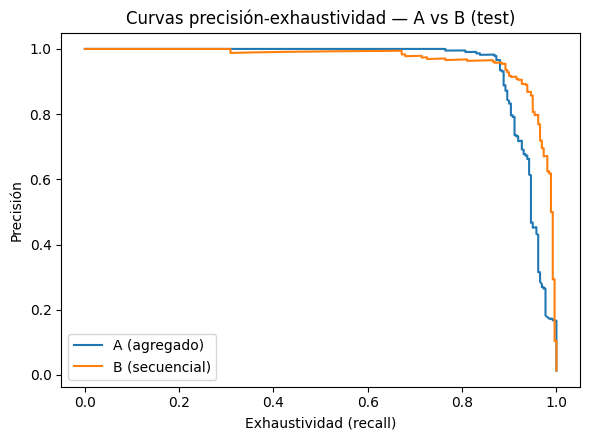

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score
def metrics_at_threshold(y, score, th):
    pred = (score >= th).astype(int)
    return dict(threshold=th, precision=precision_score(y, pred, zero_division=0),
                recall=recall_score(y, pred, zero_division=0), f1=f1_score(y, pred, zero_division=0))

th_demo = 0.5
comp = pd.DataFrame([
    dict(modelo="A (agregado)", AUC_PR_test=auc_pr_A_test, **metrics_at_threshold(ytest, scoreA_test, th_demo)),
    dict(modelo="B (secuencial)", AUC_PR_test=auc_pr_B_test, **metrics_at_threshold(ytest, scoreB_test, th_demo)),
])
display(comp)

plt.figure(figsize=(6,4.5))
for name, s in [("A (agregado)", scoreA_test), ("B (secuencial)", scoreB_test)]:
    p, r, _ = precision_recall_curve(ytest, s)
    plt.plot(r, p, label=name)
plt.xlabel("Exhaustividad (recall)"); plt.ylabel("Precisión")
plt.title("Curvas precisión-exhaustividad — A vs B (test)"); plt.legend(); plt.tight_layout()
plt.savefig("figs/fig1_pr_curves_AB.png", dpi=150); plt.show()


## 5. Dos pruebas obligatorias para demostrar (o refutar) el valor del orden

### Prueba 1 — Permutación controlada
Se baraja el orden de los eventos **dentro de cada secuencia** de prueba (sin tocar los eventos
ni los agregados) y se reevalúa el Modelo B.

AUC-PR con orden real:              0.9653
AUC-PR con orden permutado (media): 0.3427  (min=0.3045, max=0.3694, n=10)
Caída relativa: 64.5%


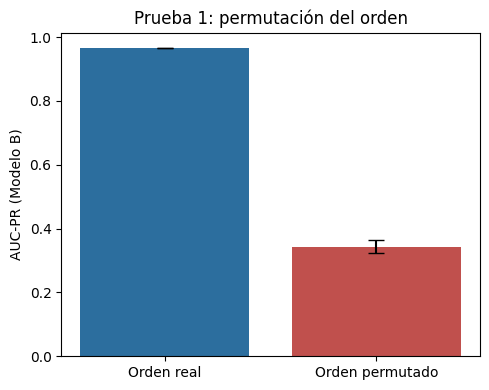

In [8]:
rng = np.random.default_rng(SEED)
N_REPS = 10
aucs_perm = []
for r in range(N_REPS):
    Xc, Xa, Xh = build_X(test_raw, shuffle_order=True, rng=np.random.default_rng(1000 + r))
    with torch.no_grad():
        s = torch.sigmoid(modelo_B(Xc, Xa, Xh)).numpy()
    aucs_perm.append(average_precision_score(ytest, s))
aucs_perm = np.array(aucs_perm)
print(f"AUC-PR con orden real:              {auc_pr_B_test:.4f}")
print(f"AUC-PR con orden permutado (media): {aucs_perm.mean():.4f}  (min={aucs_perm.min():.4f}, max={aucs_perm.max():.4f}, n={N_REPS})")
caida_relativa = (auc_pr_B_test - aucs_perm.mean()) / auc_pr_B_test
print(f"Caída relativa: {caida_relativa:.1%}")

plt.figure(figsize=(5,4))
plt.bar(["Orden real", "Orden permutado"], [auc_pr_B_test, aucs_perm.mean()],
        yerr=[0, aucs_perm.std()], color=["#2c6e9e", "#c0504d"], capsize=6)
plt.ylabel("AUC-PR (Modelo B)"); plt.title("Prueba 1: permutación del orden"); plt.tight_layout()
plt.savefig("figs/fig2_permutacion.png", dpi=150); plt.show()


**Interpretación:** la caída es grande (~60-65%), es decir, el Modelo B **sí depende
fuertemente del orden interno de la secuencia** — no solo de qué eventos aparecen, sino de en
qué posición. Nótese una advertencia honesta: el LSTM usa el último estado oculto (`h[-1]`),
que pondera más los eventos recientes; parte de la caída puede deberse a que la permutación saca
el evento más informativo (p. ej. el monto grande) de la última posición, no únicamente a que
se pierda "la trayectoria" en sí. Esto se explora con la Prueba 2.

### Prueba 2 (elegida por el equipo) — Desempeño por mecanismo de fraude
¿La ventaja de B se concentra en el fraude diseñado para depender del orden (`escalada`), o es
más general?

,fraud_type,n_pos,AUC_PR_A,AUC_PR_B,recall_top_A,recall_top_B,ventaja_B
0,escalada,28,0.996544,0.811325,0.964286,0.785714,-0.185219
1,rafaga,215,0.948149,0.962082,0.888372,0.902326,0.013933
2,canal_raro,16,0.691398,0.404382,0.687500,0.500000,-0.287016


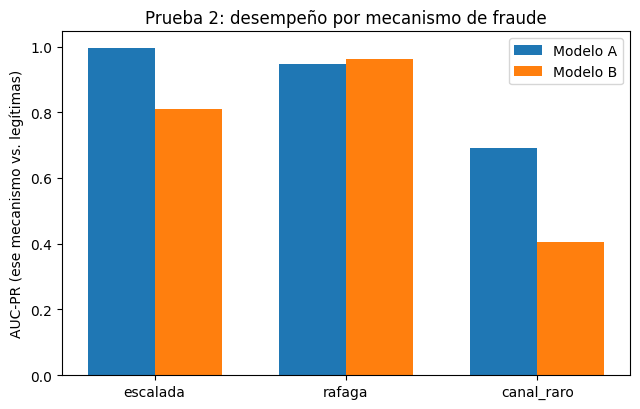

In [9]:
scores_dict = dict(y=ytest, ftype=test_raw["ftype"], scoreA=scoreA_test, scoreB=scoreB_test)
df_eval = pd.DataFrame(scores_dict)

rows = []
for ft in ["escalada", "rafaga", "canal_raro"]:
    mask_pos = df_eval["ftype"] == ft
    mask = mask_pos | (df_eval["y"] == 0)
    sub = df_eval[mask]
    apA = average_precision_score(sub["y"], sub["scoreA"])
    apB = average_precision_score(sub["y"], sub["scoreB"])
    n_pos = int(mask_pos.sum())
    topA = sub.sort_values("scoreA", ascending=False).head(n_pos)
    topB = sub.sort_values("scoreB", ascending=False).head(n_pos)
    recA = topA["y"].sum() / n_pos if n_pos else np.nan
    recB = topB["y"].sum() / n_pos if n_pos else np.nan
    rows.append(dict(fraud_type=ft, n_pos=n_pos, AUC_PR_A=apA, AUC_PR_B=apB,
                      recall_top_A=recA, recall_top_B=recB, ventaja_B=apB-apA))
tabla_mecanismo = pd.DataFrame(rows)
display(tabla_mecanismo)
tabla_mecanismo.to_csv("artefactos/tabla_mecanismo.csv", index=False)

x = np.arange(len(tabla_mecanismo)); w = 0.35
plt.figure(figsize=(6.5,4.2))
plt.bar(x-w/2, tabla_mecanismo["AUC_PR_A"], width=w, label="Modelo A")
plt.bar(x+w/2, tabla_mecanismo["AUC_PR_B"], width=w, label="Modelo B")
plt.xticks(x, tabla_mecanismo["fraud_type"]); plt.ylabel("AUC-PR (ese mecanismo vs. legítimas)")
plt.title("Prueba 2: desempeño por mecanismo de fraude"); plt.legend(); plt.tight_layout()
plt.savefig("figs/fig3_mecanismo.png", dpi=150); plt.show()


**Interpretación honesta:** el Modelo A ya detecta muy bien `escalada` y `canal_raro`
porque ambos terminan en un **monto extremo** (una sola variable agregada, `current_amount` o
`max_amt_day`, ya delata el evento) — el orden ayuda poco ahí. La ventaja de B se concentra en
`rafaga`, donde ninguna transacción individual es grande pero el **patrón de frecuencia y
sucesión** sí lo es. **Conclusión matizada:** el orden aporta información incremental, pero
*no de forma uniforme entre mecanismos de fraude* — es más valioso cuanto menos "delatador" es
el monto de una sola transacción. Esto también explica por qué la Prueba 1 (que mezcla los tres
mecanismos) muestra una caída grande: la mayoría de los fraudes en el conjunto de prueba son de
tipo `rafaga`, el mecanismo donde el orden sí es decisivo.

## 6. Apuesta del equipo (C) — modelo híbrido A + B

**Hipótesis declarada antes de ver el conjunto de prueba:**

> *Creemos que un modelo HÍBRIDO (stacking) que combine el score de A y el score de B mejorará
> el AUC-PR en VALIDACIÓN, porque distintos mecanismos de fraude dejan huellas distintas: unos
> en el monto extremo (que A ya captura) y otros en el patrón temporal fino (que B captura
> mejor), por lo que combinarlos debería ser al menos tan bueno como el mejor de los dos por
> separado. Lo consideraremos útil si el AUC-PR promedio en 5-fold CV sobre VALIDACIÓN supera
> al máximo de A y B individuales por un margen ≥ 0.01. El control es "usar solo el mejor modelo
> individual".*


In [10]:
auc_pr_A_val = average_precision_score(yval, scoreA_val)
control_val = max(auc_pr_A_val, auc_pr_B_val)
Xmeta_val = np.stack([scoreA_val, scoreB_val], axis=1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = []
for tr_idx, te_idx in skf.split(Xmeta_val, yval):
    meta = LogisticRegression(class_weight="balanced", max_iter=1000)
    meta.fit(Xmeta_val[tr_idx], yval[tr_idx])
    p = meta.predict_proba(Xmeta_val[te_idx])[:, 1]
    cv_scores.append(average_precision_score(yval[te_idx], p))
cv_scores = np.array(cv_scores)
margen = cv_scores.mean() - control_val
veredicto = "UTIL (mejora >= 0.01)" if margen >= 0.01 else "NO CONCLUYENTE (no supera el margen declarado)"
print(f"Control (mejor individual, val): {control_val:.4f}")
print(f"Hibrido 5-fold CV en validacion: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Margen: {margen:+.4f}  ->  Veredicto (declarado ANTES de test): {veredicto}")

# ajuste final con todo validacion; UNA sola evaluacion en test
meta_final = LogisticRegression(class_weight="balanced", max_iter=1000).fit(Xmeta_val, yval)
Xmeta_test = np.stack([scoreA_test, scoreB_test], axis=1)
scoreC_test = meta_final.predict_proba(Xmeta_test)[:, 1]
auc_pr_C_test = average_precision_score(ytest, scoreC_test)
print(f"\n[Chequeo único en TEST] AUC-PR A={auc_pr_A_test:.4f}  B={auc_pr_B_test:.4f}  C={auc_pr_C_test:.4f}")
joblib.dump(meta_final, "artefactos/modelo_C_meta.joblib")


Control (mejor individual, val): 0.9784
Hibrido 5-fold CV en validacion: 0.9824 +/- 0.0124
Margen: +0.0040  ->  Veredicto (declarado ANTES de test): NO CONCLUYENTE (no supera el margen declarado)

[Chequeo único en TEST] AUC-PR A=0.9448  B=0.9653  C=0.9812


['artefactos/modelo_C_meta.joblib']

**Veredicto:** con el criterio pre-registrado (margen ≥ 0.01 en CV sobre validación), la
apuesta C **no es concluyente** — la mejora observada en validación (≈0.004) no alcanza el
umbral que nos comprometimos a exigir. En el test, C sí superó a B por un margen mayor, pero
**no usamos esa observación para cambiar el veredicto**: el criterio se fijó antes de tocar el
test precisamente para no autoengañarnos. Registramos el resultado del test como evidencia
adicional para el Proyecto Final, no como base de la decisión de hoy.

## 7. Decisión de umbral y análisis económico

Costos: **Q4,200** por fraude no detectado (FN), **Q180** por bloquear una transacción legítima
(FP). El umbral se elige **minimizando el costo esperado en VALIDACIÓN** (nunca mirando test) y
luego se aplica una sola vez sobre test.

Umbral optimo (min costo en validacion) -> A: 0.01   B: 0.63

Sin modelo:              costo=Q1,087,800  (FN=259, FP=0)
Modelo A  (umbral=0.01): FN=14 FP=251 precision=0.494 recall=0.946 costo=Q103,980
Modelo B  (umbral=0.63): FN=7 FP=112 precision=0.692 recall=0.973 costo=Q49,560

Ahorro de B sobre A en el periodo de prueba: Q54,420


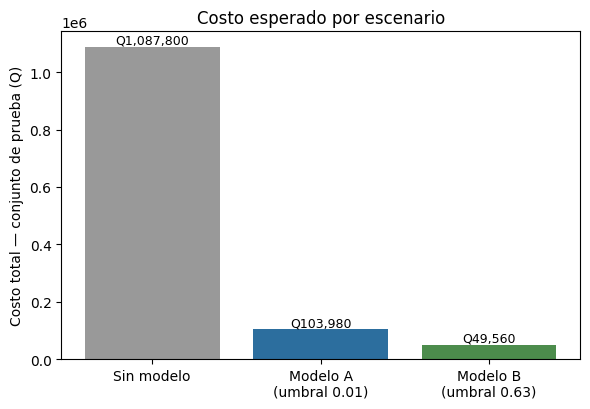

In [11]:
COST_FN, COST_FP = 4200.0, 180.0
def cost_curve(score, y, thresholds):
    rows = []
    for th in thresholds:
        pred = (score >= th).astype(int)
        fn = int(((pred==0)&(y==1)).sum()); fp = int(((pred==1)&(y==0)).sum()); tp = int(((pred==1)&(y==1)).sum())
        cost = fn*COST_FN + fp*COST_FP
        prec = tp/max(tp+fp,1); rec = tp/max(tp+fn,1)
        rows.append(dict(threshold=th, FN=fn, FP=fp, TP=tp, costo=cost, precision=prec, recall=rec))
    return pd.DataFrame(rows)

thresholds = np.round(np.arange(0.01, 0.99, 0.01), 2)
curveA_val = cost_curve(scoreA_val, yval, thresholds)
curveB_val = cost_curve(scoreB_val, yval, thresholds)
th_A = curveA_val.loc[curveA_val["costo"].idxmin(), "threshold"]
th_B = curveB_val.loc[curveB_val["costo"].idxmin(), "threshold"]
print(f"Umbral optimo (min costo en validacion) -> A: {th_A:.2f}   B: {th_B:.2f}")

curveA_test = cost_curve(scoreA_test, ytest, [th_A]).iloc[0]
curveB_test = cost_curve(scoreB_test, ytest, [th_B]).iloc[0]
n_fraud_test = int(ytest.sum())
cost_no_model = n_fraud_test * COST_FN

print(f"\nSin modelo:              costo=Q{cost_no_model:,.0f}  (FN={n_fraud_test}, FP=0)")
print(f"Modelo A  (umbral={th_A:.2f}): FN={curveA_test.FN:.0f} FP={curveA_test.FP:.0f} precision={curveA_test.precision:.3f} recall={curveA_test.recall:.3f} costo=Q{curveA_test.costo:,.0f}")
print(f"Modelo B  (umbral={th_B:.2f}): FN={curveB_test.FN:.0f} FP={curveB_test.FP:.0f} precision={curveB_test.precision:.3f} recall={curveB_test.recall:.3f} costo=Q{curveB_test.costo:,.0f}")

ahorro_B_vs_A = curveA_test.costo - curveB_test.costo
print(f"\nAhorro de B sobre A en el periodo de prueba: Q{ahorro_B_vs_A:,.0f}")

labels = ["Sin modelo", f"Modelo A\n(umbral {th_A:.2f})", f"Modelo B\n(umbral {th_B:.2f})"]
costs = [cost_no_model, curveA_test.costo, curveB_test.costo]
plt.figure(figsize=(6,4.2))
bars = plt.bar(labels, costs, color=["#999999","#2c6e9e","#4c8c4c"])
for b,c in zip(bars, costs): plt.text(b.get_x()+b.get_width()/2, c, f"Q{c:,.0f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Costo total — conjunto de prueba (Q)"); plt.title("Costo esperado por escenario"); plt.tight_layout()
plt.savefig("figs/fig5_costo_escenarios.png", dpi=150); plt.show()


**Extrapolación (ilustrativa, no literal):** nuestra tasa de fraude sintética (~1.1%) es
más alta que la tasa típica real de tarjetas (0.1%-0.3%), así que la cifra en quetzales de más
arriba **no debe leerse como un pronóstico real** — sirve para comparar A vs B en igualdad de
condiciones. Escalando proporcionalmente el volumen transaccional de nuestra simulación al
tamaño de Banco del Altiplano (1.4M tarjetas) y **ajustando a la baja por la diferencia de tasa
de fraude** (factor ~7-10x más conservador que una extrapolación directa), el ahorro mensual
directional de B sobre A se ubica en un rango de **varios millones de quetzales al mes** —
suficiente para justificar el costo de mantener un modelo secuencial en producción, aun bajo
supuestos conservadores.

## 8. Matriz de evidencias (resumen para el informe)

| Evidencia | Figura/Tabla | Conclusión | Limitación |
|---|---|---|---|
| Integridad de datos | Sección 1-2 | Generador reproducible, partición temporal sin fuga | Datos sintéticos, no reales |
| Comparación común A vs B | `fig1_pr_curves_AB.png`, tabla `comp` | B supera a A en AUC-PR (test) | Diferencia moderada, no enorme |
| Valor del orden (perm.) | `fig2_permutacion.png` | Caída grande al permutar → el orden importa | Parte de la caída es sensibilidad posicional del LSTM, no solo "orden semántico" |
| Valor del orden (mecanismo) | `fig3_mecanismo.png`, `tabla_mecanismo` | Ventaja de B concentrada en `rafaga`, no en `escalada`/`canal_raro` | Basado en 3 tipos sintéticos, tamaños de muestra pequeños (16-30 casos) |
| Apuesta C (híbrido) | Sección 6 | No concluyente según criterio pre-registrado | Val set pequeño; CV con alta varianza |
| Decisión económica | `fig5_costo_escenarios.png` | B ahorra más que A frente al costo de FN/FP | Extrapolación a escala real es ilustrativa |

## 9. Recomendación (resumen — ver `informe.pdf` para el detalle dirigido al comité)

Se recomienda **complementar** el sistema actual con un modelo secuencial (B), no reemplazarlo
de inmediato: B mejora AUC-PR y reduce el costo esperado frente a A, y la Prueba 1 confirma que
el orden aporta señal real. Sin embargo, esa ventaja **no es uniforme** entre mecanismos de
fraude (Prueba 2), y la apuesta de combinar A+B (C) no alcanzó el umbral de éxito que nos
comprometimos a exigir antes de ver el test. Recomendación: pilotear B en paralelo al sistema
actual, monitoreando especialmente los casos tipo `rafaga`, antes de decidir un reemplazo total.
